<div style="background: linear-gradient(135deg, #1e3a8a 0%, #3b82f6 100%); padding: 30px; border-radius: 15px; text-align: center; color: white; box-shadow: 0 10px 20px rgba(0,0,0,0.2); margin-bottom: 20px;">
    <h1 style="margin: 0; font-size: 2.5em; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 800; letter-spacing: 2px; text-transform: uppercase;">
        Disaster Tweets Analysis
    </h1>
    <hr style="border: 0; height: 1px; background-image: linear-gradient(to right, rgba(255, 255, 255, 0), rgba(255, 255, 255, 0.75), rgba(255, 255, 255, 0)); margin: 15px 0;">
    <h2 style="margin: 0; font-size: 1.5em; opacity: 0.9; font-weight: 400; font-style: italic;">
        Réseaux de neurones LSTM
    </h2>
</div>

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Importations
</h3>


In [1]:
import builtins
import pandas as pd

# Suivi des expriences (MLflow & DagsHub)
import dagshub
import mlflow

# Scikit-Learn : Sparation des donnes et mtriques d'valuation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    f1_score, 
    fbeta_score, 
    precision_score, 
    recall_score
)

# TensorFlow / Keras : Cration et entranement du modle Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import TextVectorization


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    DagsHub & MLflow Init
</h3>


In [2]:
# Initialisation de la connexion DagsHub avec les identifiants de votre dépôt et activation du mode MLflow
# PATCH WINDOWS : Force l'utilisation de l'encodage UTF-8 lors de l'écriture des fichiers.

_original_open = builtins.open
def _utf8_open(*args, **kwargs):
    mode = kwargs.get('mode', args[1] if len(args) > 1 else 'r')
    if 'b' not in mode and 'encoding' not in kwargs:
        kwargs['encoding'] = 'utf-8'
    return _original_open(*args, **kwargs)
builtins.open = _utf8_open

dagshub.init(repo_owner='Oscar-AS', repo_name='disaster-tweets-project', mlflow=True)

# Définition du nom du dossier (expérience) dans MLflow où toutes nos métriques seront classées
mlflow.set_experiment("Disaster_Tweets")

# Affichage d'un message console pour confirmer que le tracking est bien connecté
print("MLflow activé avec succès sur DagsHub !")


Accessing as Oscar-AS

Initialized MLflow to track repo "Oscar-AS/disaster-tweets-project"

Repository Oscar-AS/disaster-tweets-project initialized!

MLflow activé avec succès sur DagsHub !


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Importation Données
</h3>


In [4]:

# Chargement des données
df = pd.read_csv("../Base/tweets.csv")

In [8]:
df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,communal violence in bhainsa telangana stones ...,1
1,1,ablaze,NaN,telangana section has been imposed in bhainsa ...,1
2,2,ablaze,New York City,arsonist sets cars ablaze at dealership,1
3,3,ablaze,"Morgantown, WV",arsonist sets cars ablaze at dealership,1
4,4,ablaze,NaN,lord jesus your love brings freedom and pardon...,0


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Nettoyage
</h3>


In [6]:
import re

def cleaning_simple(data):
    text = str(data)  # convertir en texte pour éviter les erreurs avec les valeurs manquantes
    
    text = re.sub(r'https?://\S+|www\.\S+|http?://\S+', ' ', text)  # supprimer les URLs
    
    text = re.sub(r'<.*?>', ' ', text)  # supprimer les balises HTML
    
    text = re.sub("["
                  u"\U0001F600-\U0001F64F"
                  u"\U0001F300-\U0001F5FF"
                  u"\U0001F680-\U0001F6FF"
                  u"\U0001F1E0-\U0001F1FF"
                  u"\U00002702-\U000027B0"
                  u"\U000024C2-\U0001F251"
                  "]+", ' ', text)  # supprimer les émojis et symboles
    
    text = re.sub(r'@\S+', ' ', text)  # supprimer les mentions @user
    
    text = re.sub(r'#', '', text)  # supprimer le symbole # mais garder le mot
    
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # garder uniquement les lettres et les espaces
    
    text = text.lower()  # convertir en minuscules
    
    text = re.sub(r'\s+', ' ', text).strip()  # supprimer les espaces multiples
    
    return text

In [7]:
df["text"] = df["text"].apply(cleaning_simple)

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Séparation des données
</h3>


In [9]:

# Séparation Train/Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# Affiche dans la console le nombre de tweets utilisés pour l'entraînement
print(f"Taille de l'entraînement : {len(X_train)}")
# Affiche dans la console le nombre de tweets gardés pour le test
print(f"Taille du test : {len(X_test)}")


Taille de l'entraînement : 9096
Taille du test : 2274


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Implémentation des modèles (Réseaux de Neurones avec TensorFlow/Keras)
</h3>


In [10]:

# Définition de la taille maximale du vocabulaire autorisé (les 15000 mots les plus fréquents)
MAX_VOCAB_SIZE = 15000
# Définition de la taille maximale d'une phrase (tronquée si plus longue, remplie par des 0 si plus courte)
MAX_SEQUENCE_LENGTH = 128

# Instanciation de la couche de Vectorisation
vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE, # Limite du vocabulaire
    output_mode='int',         # Chaque mot sera remplacé par un nombre entier
    output_sequence_length=MAX_SEQUENCE_LENGTH # Fixe la longueur de toutes les séquences à 128
)

# Apprentissage du vocabulaire : on lit le texte d'entraînement pour créer le dictionnaire mot -> entier
vectorizer.adapt(X_train.to_numpy())

# Fonction utilitaire pour préparer les données afin que TensorFlow s'entraîne plus vite
def prepare_tf_dataset(X, y, batch_size=32):
    # Création d'un dataset TensorFlow à partir de nos listes Python (X et y)
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    # Groupement des données en paquets (batches) de 32, et mise en mémoire cache dynamique (AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    # Retourne le dataset optimisé
    return dataset

# Création du Dataset d'entraînement accéléré
train_ds = prepare_tf_dataset(X_train, y_train)
# Création du Dataset de test accéléré
test_ds = prepare_tf_dataset(X_test, y_test)

# Importation du module MLflow dédié à TensorFlow
import mlflow.tensorflow
# Activation du suivi automatique (enregistrera la loss, les paramètres et les modèles à chaque epoch sans coder manuellement)
mlflow.tensorflow.autolog(log_models=True)


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Modèle LSTM (Long Short-Term Memory) Simple
</h3>

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Description du modèle
</h3>
Le LSTM est l'architecture classique des réseaux de neurones pour le traitement de texte. Il appartient à la famille des Réseaux de Neurones Récurrents (RNN).

<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Explication du fonctionnement
</h3>
Contrairement aux réseaux classiques qui traitent l'information d'un bloc, le LSTM lit le texte mot par mot, de gauche à droite. Il possède une "mémoire interne" (une bande transporteuse mathématique) qui lui permet de se souvenir du début de la phrase quand il arrive à la fin. Cela lui permet de comprendre le contexte.




In [11]:
# Importation des types de couches (layers) et de l'architecture séquentielle (models) de Keras
# Importation de la fonction générant un rapport complet de classification (F1, Precision, Recall, etc.)

# Démarrage manuel d'une instance (run) MLflow nommée "3.1_LSTM_Simple"
with mlflow.start_run(run_name="LSTM_Simple"):
    # Définition de la métrique F2-Score pour Keras
    def f2_score(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())
        return (1 + 4) * (precision * recall) / (4 * precision + recall + tf.keras.backend.epsilon())

    # Initialisation d'un réseau de neurones en couches successives (Sequential)
    model_lstm = models.Sequential([
        # Couche 1 : Vectorisation (transforme le texte brut en liste d'entiers)
        vectorizer,
        # Couche 2 : Embedding (transforme l'entier en un vecteur mathématique dense de dimension 64)
        layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=64, mask_zero=True),
        # Couche 3 : LSTM (le coeur récurrent, avec 64 neurones)
        layers.LSTM(64),
        # Couche 4 : Couche finale (Dense) avec 1 neurone et une activation Sigmoid (renvoie une probabilité entre 0 et 1)
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Compilation du modèle : définition de la fonction d'erreur (binary_crossentropy) et de l'optimiseur (adam)
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_lstm.keras',
        monitor='val_f2_score',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', f2_score])
    # Lancement de l'entraînement sur 3 itérations (epochs), en validant sur test_ds à chaque fin d'epoch
    model_lstm.fit(train_ds, validation_data=test_ds, epochs=3, callbacks=[checkpoint_cb])
    
    # Recharger le meilleur modèle
    model_lstm = models.load_model('best_model_lstm.keras', custom_objects={'f2_score': f2_score})
    
    # Prédiction sur le jeu de test. Si la probabilité est > 0.5, on classe 1 (Désastre), sinon 0 (astye(int) convertit False/True en 0/1)
    y_pred_lstm = (model_lstm.predict(test_ds) > 0.5).astype(int)
     
    print("\n--- Rapport LSTM Simple ---")
    # Affichage des résultats complets en confrontant les vraies valeurs (y_test) aux prédictions (y_pred_lstm)
    print(classification_report(y_test, y_pred_lstm))
    
    # Suivi explicite des métriques de test dans MLflow
    mlflow.log_metric("eval_f1_macro", f1_score(y_test, y_pred_lstm, average='macro'))
    mlflow.log_metric("eval_f2_score", fbeta_score(y_test, y_pred_lstm, beta=2, average='macro'))
    
    precision_cls = precision_score(y_test, y_pred_lstm, average=None)
    recall_cls = recall_score(y_test, y_pred_lstm, average=None)
    mlflow.log_metric("eval_precision_class_0", precision_cls[0])
    mlflow.log_metric("eval_precision_class_1", precision_cls[1])
    mlflow.log_metric("eval_recall_class_0", recall_cls[0])
    mlflow.log_metric("eval_recall_class_1", recall_cls[1])
    mlflow.log_metric("eval_accuracy", accuracy_score(y_test, y_pred_lstm))
    
    # Enregistrement explicite du modèle pour la mise en production
    try:
        mlflow.tensorflow.log_model(model_lstm, "model")
    except Exception as e:
        print("Erreur lors de la sauvegarde du modèle Keras :", e)


2026/05/08 12:26:16 WARNING mlflow.tensorflow: Encountered unexpected error while inferring batch size from training dataset: Sequential model 'sequential' has no defined input shape yet.


Epoch 1/3
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8236 - f2_score: 0.0486 - loss: 0.4606
Epoch 1: val_f2_score improved from None to 0.12848, saving model to best_model_lstm.keras

Epoch 1: finished saving model to best_model_lstm.keras


285/285 ━━━━━━━━━━━━━━━━━━━━ 80s 269ms/step - accuracy: 0.8610 - f2_score: 0.0927 - loss: 0.3700 - val_accuracy: 0.8861 - val_f2_score: 0.1285 - val_loss: 0.3002
Epoch 2/3
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9258 - f2_score: 0.1658 - loss: 0.1986
Epoch 2: val_f2_score improved from 0.12848 to 0.14725, saving model to best_model_lstm.keras

Epoch 2: finished saving model to best_model_lstm.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step - accuracy: 0.9371 - f2_score: 0.1707 - loss: 0.1770 - val_accuracy: 0.8874 - val_f2_score: 0.1472 - val_loss: 0.3151
Epoch 3/3
284/285 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9699 - f2_score: 0.1791 - loss: 0.0971
Epoch 3: val_f2_score did not improve from 0.14725
285/285 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.9722 - f2_score: 0.1802 - loss: 0.0887 - val_accuracy: 0.8843 - val_f2_score: 0.1392 - val_loss: 0.4011


2026/05/08 12:28:27 WARNING mlflow.tensorflow: Failed to infer model signature: Invalid dtype: object
2026/05/08 12:28:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 12:28:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/08 12:28:53 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmp22m4p1c9\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables wh

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

--- Rapport LSTM Simple ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1851
           1       0.77      0.57      0.65       423

    accuracy                           0.89      2274
   macro avg       0.84      0.76      0.79      2274
weighted avg       0.88      0.89      0.88      2274



2026/05/08 12:30:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 12:31:02 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/08 12:31:13 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmpcakew620\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


🏃 View run LSTM_Simple at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4/runs/65282718a3ba4066a2e395ced7888308
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4


In [ ]:
# Tableau récapitulatif des métriques du modèle LSTM
report_lstm = classification_report(y_test, y_pred_lstm, output_dict=True, zero_division=0)
f2_class_lstm = fbeta_score(y_test, y_pred_lstm, beta=2, average=None, zero_division=0)
f2_macro_lstm = fbeta_score(y_test, y_pred_lstm, beta=2, average="macro", zero_division=0)
f2_weighted_lstm = fbeta_score(y_test, y_pred_lstm, beta=2, average="weighted", zero_division=0)

metrics_table_lstm = (
    pd.DataFrame(report_lstm)
    .transpose()
    .rename(index={
        "0": "Non disaster",
        "1": "Disaster",
        "accuracy": "Accuracy",
        "macro avg": "Macro average",
        "weighted avg": "Weighted average",
    })
)

metrics_table_lstm["f2-score"] = pd.NA
metrics_table_lstm.loc["Non disaster", "f2-score"] = f2_class_lstm[0]
metrics_table_lstm.loc["Disaster", "f2-score"] = f2_class_lstm[1]
metrics_table_lstm.loc["Macro average", "f2-score"] = f2_macro_lstm
metrics_table_lstm.loc["Weighted average", "f2-score"] = f2_weighted_lstm

metrics_table_lstm = metrics_table_lstm[["precision", "recall", "f1-score", "f2-score", "support"]]
metrics_table_lstm.round(3)


<h3 style="color: #1e40af; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 25px; font-weight: bold; font-family: 'Segoe UI', sans-serif;">
    Commentaire sur les résultats du LSTM
</h3>

Le modèle obtient une accuracy d'environ **89 %**, ce qui montre qu'il classe correctement une grande partie des tweets. 

Le modèle reconnaît très bien les tweets **non disaster** : le rappel de la classe 0 est élevé, autour de **96 %**. En revanche, pour les tweets **disaster**, le rappel est plus faible, autour de **57 %**. Cela veut dire que le modèle rate encore une partie importante des vrais tweets de catastrophe.

Le **F2-score** confirme cette lecture. Cette métrique donne plus de poids au rappel qu'à la précision.



 1/72 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step


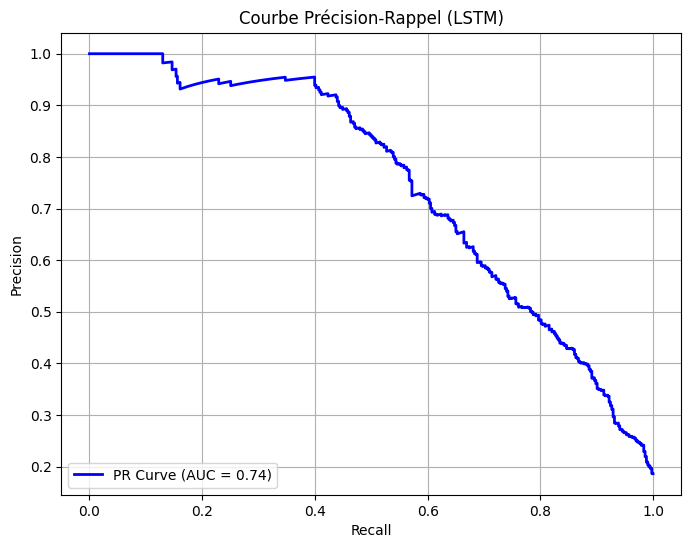

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import pandas as pd

# 1. Calcul des probabilités de prédiction
y_probs_lstm = model_lstm.predict(test_ds).ravel()

# 2. Courbe Précision-Rappel
precision, recall, _ = precision_recall_curve(y_test, y_probs_lstm)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Précision-Rappel (LSTM)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

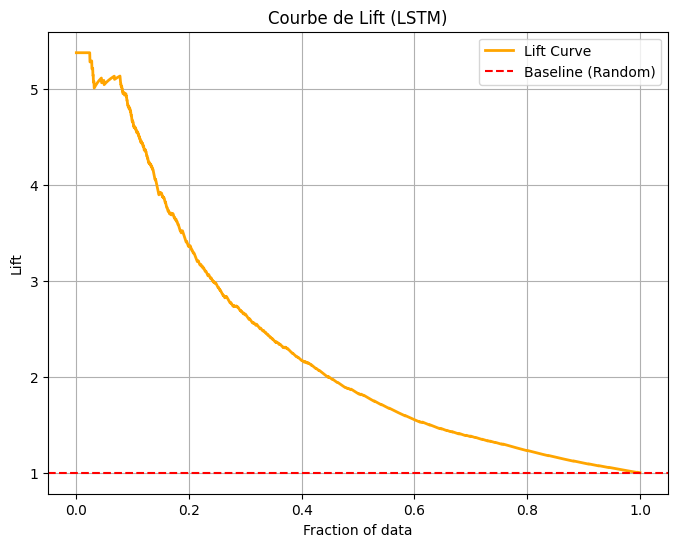

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Courbe de Lift
# Trier les probabilités par ordre décroissant
data = pd.DataFrame({'y_true': y_test, 'y_prob': y_probs_lstm})
data = data.sort_values(by='y_prob', ascending=False)
data['cumulative_data_fraction'] = np.arange(1, len(data) + 1) / len(data)
data['cumulative_positive_rate'] = data['y_true'].cumsum() / data['y_true'].sum()
data['lift'] = data['cumulative_positive_rate'] / data['cumulative_data_fraction']

plt.figure(figsize=(8, 6))
plt.plot(data['cumulative_data_fraction'], data['lift'], label='Lift Curve', color='orange', lw=2)
plt.axhline(y=1, color='r', linestyle='--', label='Baseline (Random)')
plt.xlabel('Fraction of data')
plt.ylabel('Lift')
plt.title('Courbe de Lift (LSTM)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()